In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import lstsq
from npeet import entropy_estimators as ee

In [ ]:
# setup
np.random.seed(42)

timesteps = {
    # phases
    "plasticity": 20000,
    "train": 5000,
    "test": 5000,
}

timesteps["total"] = (timesteps["plasticity"] +
                        timesteps["train"] +
                        timesteps["train"])


hyperparameters = {
    # network parameters
    "n": 100,  # num neurons
    "k": 12,  # winners
    "eta_sp": 0.001,  # learning rate for synaptic plasticity
    "eta_ip": 0.001,  # learning rate for intrinsic plasticity
    # very poor performance when eta_sp and eta_ip are 0.01

    # task parameters
    "n_symbols": 4,  # A, B, C, D
    "rf_size": 15,  # receptive field size for each symbol
    "drive_strength": 0.25,  # input drive value

    "timesteps": timesteps,

    "verbosity": 0,

    # Perturbation
    "pi": 12,

}

## 1. Network Architecture

The recurrent network is of the k-Winner-Take-All (kWTA) type. The paper describes it as follows:

"the model recurrent network is of the k-Winner-Take-All (kWTA) type that consists of n
memoryless binary neurons from which only k neurons are active."

The network state at each timestep is governed by:

$$x(t+1) = f(w \cdot x(t) - h + d(t)) \tag{1}$$

where:
- $x \in \{0,1\}^n$ is the network state vector (binary, exactly $k$ neurons active)
- $w \in [0,1]^{n \times n}$ is the recurrent weight matrix, with $w_{ij}$ being the
  synaptic efficacy from neuron $j$ to neuron $i$, and $w_{ii} = 0$ (no self-connections)
- $h \in \mathbb{R}^n$ is the vector of firing thresholds, modulating each neuron's
  resistance to firing
- $d(t) \in \mathbb{R}^n$ is the external drive at timestep $t$
- $f(\cdot)$ is the kWTA nonlinearity, which sets the $k$ neurons with the highest
  pre-activation to 1 and the rest to 0

Parameters are initialized as follows. The weight matrix is sparse with 10% connectivity,
with nonzero values drawn uniformly from $[0, 0.1]$. Thresholds are drawn from a Gaussian
distribution with mean 0 and standard deviation 0.1. The initial network state is a random
valid kWTA state with exactly $k$ active neurons.

In [15]:
class Kwta_RN:
    # k-Winners-Take-All Recurrent Network
    def __init__(self, hp):
        self.n = hp["n"]
        self.k = hp["k"]

    def init_network(self):

        w = np.random.uniform(0, 0.1, (self.n, self.n))
        mask = np.random.rand(self.n, self.n) < 0.1
        w = w * mask
        np.fill_diagonal(w, 0)

        h = np.random.normal(0, 0.1, self.n)
        x = self.generate_random_kwta_state()

        return w, h, x


    def generate_random_kwta_state(self):
        active_neurons = np.random.choice(self.n, self.k, replace=False)
        x = np.zeros(self.n)

        for neuron in active_neurons:
            x[neuron] = 1

        return x

    def kWTA(self, input_vector, k):
        top_k_indices = np.argsort(input_vector)[-k:]
        output_vector = np.zeros_like(input_vector)
        output_vector[top_k_indices] = 1
        return output_vector

## 2. External Drive and Receptive Fields

The external drive encodes the current input symbol as a sparse activation pattern over
a fixed subset of neurons. The paper describes this as:

"The external drive $\delta$ consists of discrete symbols that follow a certain stochastic
dynamics, and each projects to a corresponding receptive field (RF)."

For the RAND x 4 task, 4 symbols {A, B, C, D} are drawn uniformly at random. Each symbol
maps to a non-overlapping receptive field of 15 neurons (neurons 0-14, 15-29, 30-44, 45-59
respectively). When symbol $p$ is presented, the neurons in its receptive field receive a
drive of $d = 0.25$, while all other neurons receive zero drive. The remaining 40 neurons
(60-99) participate only through recurrent connections and receive no direct external input.

A separate symbol stream is generated independently for each phase (plasticity, training,
testing) to prevent any overlap between the data used for learning and evaluation.

In [16]:
class Drive:

    def __init__(self, hp):
        self.strength = hp["drive_strength"]
        self.n = hp["n"]
        self.num_symbols = hp["n_symbols"]
        self.total_timesteps = hp["timesteps"]["total"]

        # Receptive fields: fixed, non-overlapping
        # RF[A] = neurons 0–14
        # RF[B] = neurons 15–29
        # RF[C] = neurons 30–44
        # RF[D] = neurons 45–59

        self.rf = {
            0: list(range(0, 15)),     # A
            1: list(range(15, 30)),    # B
            2: list(range(30, 45)),    # c
            3: list(range(45, 60))     # D
        }
        # neurons 60–99 belong to no receptive field

    def get_symbol(self, symbols, t):
        symbol = symbols[t]
        return self.make_drive(symbol)

    def generate_symbols(self, l):
        return np.random.randint(self.num_symbols, size=l)

    def make_drive(self, symbol):
        drive = np.zeros(self.n)
        for neuron in self.rf[symbol]:
            drive[neuron] = self.strength

        return drive

## 3. Plasticity Phase

The plasticity phase runs for 20,000 timesteps. During this phase, the network receives
the input symbol stream and both plasticity mechanisms update the network parameters at
every timestep. After the plasticity phase, $w$ and $h$ are frozen and never modified again.

### 3.1 Network Update

At each timestep, the network state is updated according to Equation 1 above.

### 3.2 Spike-Timing-Dependent Synaptic Plasticity (STDP)

STDP modifies the weight matrix $w$ based on the relative firing times of pre- and
post-synaptic neurons. The paper uses a simplified causal rule:

"a synapse is potentiated whenever the pre-synaptic neuron fires one time step before
the post-synaptic neuron, and is depressed when a post-synaptic spike precedes a
pre-synaptic spike by one time step"

$$\Delta w_{ij}(t+1) = \eta_{sp} \left[ x_j(t) \cdot x_i(t+1) - x_i(t) \cdot x_j(t+1) \right] \tag{3}$$

where $\eta_{sp} = 0.001$ is the synaptic learning rate. Weights are clipped to $[0, 1]$
and self-connections are zeroed after each update.

### 3.3 Intrinsic Plasticity (IP)

IP modifies the firing threshold vector $h$ to regulate each neuron's firing rate toward
the population average $k/n$:

$$\Delta h_i(t+1) = \eta_{ip} \left( x_i(t+1) - k/n \right) \tag{4}$$

where $\eta_{ip} = 0.001$ is the intrinsic plasticity learning rate. Neurons that fire
more than the population average have their threshold increased (harder to fire), while
neurons that fire less have their threshold decreased (easier to fire). This prevents
any single neuron from dominating the network activity.

In [23]:
def plasticity_phase(external_drive, network, hp):

    w, h, x = network.init_network()

    plasticity_timesteps = hp["timesteps"]["plasticity"]
    k = hp["k"]
    n = hp["n"]
    eta_sp = hp["eta_sp"]
    eta_ip = hp["eta_ip"]

    w = w.copy()
    h = h.copy()
    x = x.copy()

    symbols = external_drive.generate_symbols(plasticity_timesteps)

    for t in range(plasticity_timesteps):

        drive = external_drive.get_symbol(symbols, t)

        # compute pre-activation for all neurons
        pre_activation = w @ x - h + drive

        # apply kWTA: set top k pre-activations to 1, rest to 0
        x_new = network.kWTA(pre_activation, k=hp['k'])

        # STDP update (needs both x at t and x_new at t+1)
        dw = eta_sp * (np.outer(x_new, x) - np.outer(x, x_new))
        w = w + dw
        w = np.clip(w, 0, 1)
        np.fill_diagonal(w, 0)

        # IP update
        dh = eta_ip * (x_new - k / n)
        h = h + dh

        x = x_new

    print("Done running plasticity.")

    return w, h, x

## 4. Post-Plasticity Perturbation

After the plasticity phase, the network state is perturbed before training begins. The
paper describes this as:

"This perturbation is applied to the end state of the plasticity phase, such that the
end state of the plasticity phase and the initial state of the training phase are at a
distance $2\pi$ from one another."

The perturbation works by selecting $\pi$ currently firing neurons and silencing them,
while simultaneously selecting $\pi$ currently silent neurons and activating them. The
result is a valid kWTA state (still exactly $k$ active neurons) at a Hamming distance
of $2\pi$ from the end state of the plasticity phase.

The paper uses $\pi = 12$ for the main results in Figure 2, which corresponds to
replacing all active neurons with a new random set, equivalent to a fully random
re-initialization. The perturbation is necessary because without it, the network
remains in its input-insensitive dynamic regime and performs at chance level.

In [24]:
def perturbation_phase(x, hp):

    k = hp["k"]
    pi = hp["pi"]

    x_end = x.copy()

    firing = np.where(x_end == 1)[0]
    silent = np.where(x_end == 0)[0]

    flip_off = np.random.choice(firing, size=pi, replace=False)
    flip_on = np.random.choice(silent, size=pi, replace=False)

    x_purturb = x_end.copy()
    x_purturb[flip_off] = 0
    x_purturb[flip_on] = 1

    assert x_purturb.sum() == k, "Perturbed state must still have exactly k active neurons"

    print("Done running perturbation.")

    return x_purturb

## 5. Training Phase

The training phase runs for 5,000 timesteps with $w$ and $h$ frozen. Network states
are collected and used to train a linear readout via linear regression. The paper
describes the readout as:

"Output weights from the recurrent network to linear readouts are computed with
linear regression so that the readouts activity is the optimal linear classifier
of a target signal."

The training data matrix is:

$$X_{tr} = \left\{ x(t)^T \right\}_{t_{pl} < t \leq t_{pl} + t_{tr}} \tag{5}$$

where $t_{pl} = 20000$ is the end of the plasticity phase and $t_{tr} = 5000$ is the
training phase length. For a given time lag $\tau$, the target label at timestep $t$
is the symbol that appeared at time $t + \tau$. Negative $\tau$ corresponds to recall
of past symbols, positive $\tau$ to prediction of future symbols.

The output weights are computed via ordinary least squares:

$$w^{(\tau)} = (X_{tr}^T X_{tr})^{-1} X_{tr}^T \cdot O^{(\tau)}_{tr} \tag{7}$$

where $O^{(\tau)}_{tr}$ is the one-hot encoded target matrix of shape $(T, n_{symbols})$.

In [25]:
def train_phase(w, h, x, external_drive, network, hp):

    train_timesteps = hp["timesteps"]["train"]
    k = hp["k"]
    n = hp["n"]
    tau = hp["tau"]
    n_symbols = hp["n_symbols"]

    states_train = []
    labels_train = []

    symbols = external_drive.generate_symbols(train_timesteps)

    for t in range(train_timesteps):

        drive = external_drive.get_symbol(symbols, t)

        pre_activation = w @ x - h + drive

        x = network.kWTA(pre_activation, k=k)

        label_t = t + tau
        if 0 <= label_t < len(symbols):
            states_train.append(x.copy())
            labels_train.append(symbols[label_t])

    print("Done training.")

    X_train =  np.array(states_train) # shape (train_timesteps -1, n)
    y_train = np.array(labels_train) # shape (train_timesteps -1,)

    Y_train = np.zeros((len(y_train), n_symbols))
    Y_train[np.arange(len(y_train)), y_train] = 1

    w_out, _, _, _ = lstsq(X_train, Y_train) # shape (n, 4)

    return w_out

## 6. Testing Phase

The testing phase runs for 5,000 timesteps with a fresh random initial state. The
trained readout weights $w^{(\tau)}$ are applied to the collected test states to
produce predictions.

The test states are collected as:

$$X_{ts} = \left\{ x(t)^T \right\}_{t_{pl}+t_{tr} < t \leq t_{pl}+t_{tr}+t_{ts}} \tag{8}$$

The readout output is computed as:

$$\tilde{O}^{(\tau)} = X_{ts} \cdot w^{(\tau)} \tag{9}$$

For each timestep, the predicted symbol is the argmax over the readout output. The
classification performance is the fraction of correct predictions:

$$P^{(\tau)} = \frac{100}{t_{ts}} \sum_{t=1}^{t_{ts}} \mathbf{1}\left[ \hat{y}(t) = y(t) \right] \tag{10}$$

where $\hat{y}(t)$ is the predicted symbol and $y(t)$ is the true label at lag $\tau$.
Chance level is $100 / n_{symbols} = 25\%$ for the 4-symbol tasks.

In [26]:
def test_phase(w, h, x, w_out, network, external_drive, hp):
    # testing phase

    test_timesteps = hp["timesteps"]["test"]
    k = hp["k"]
    tau = hp["tau"]

    x = network.generate_random_kwta_state()

    states_test = []
    labels_test = []

    symbols = external_drive.generate_symbols(test_timesteps)

    for t in range(test_timesteps):

        drive = external_drive.get_symbol(symbols, t)

        pre_activation = w @ x - h + drive

        x = network.kWTA(pre_activation, k=k)

        label_t = t + tau
        if 0 <= label_t < len(symbols):
            states_test.append(x.copy())
            labels_test.append(symbols[label_t])

    X_test = np.array(states_test)  # shape (test_timesteps, n)
    y_test = np.array(labels_test)  # shape (test_timesteps,)

    # apply readout
    scores = X_test @ w_out  # shape (test_timesteps, 4)
    predictions = np.argmax(scores, axis=1)  # shape (test_timesteps,)

    # compute performance
    performance = np.mean(predictions == y_test) * 100

    print(f"Done testing.")

    return performance

## 7. Entropy and Mutual Information

After the plasticity phase, the quality of the network's internal representations is
measured using two information-theoretic quantities. These are computed on a separate
forward run using the frozen network, independent of the training and testing phases.

**Network state entropy** measures the richness of the network's state repertoire:

$$H(X) = -\sum_{x \in X} p(x) \log_2 p(x) \tag{11}$$

A higher entropy means the network visits more distinct states, corresponding to a
richer code. The paper reports that SP-RNs collapse to approximately 2 bits (4 states),
while SIP-RNs reach 5-7 bits after 20,000 plasticity steps.

**Mutual information** measures how much the network state reflects the input sequence:

$$I(U, X) = \sum_{u \in U} \sum_{x \in X} p(u,x) \log_2 \frac{p(u,x)}{p(u) \cdot p(x)} \tag{12}$$

where $U$ is the sequence of the three most recent input symbols, encoded with a 3-bit
code that ensures equal pairwise Hamming distances between symbols:
$A=[0,0,0]$, $B=[0,1,1]$, $C=[1,0,1]$, $D=[1,1,0]$. An optimal encoder would
achieve $I(U,X) = \log_2(4^3) = 6$ bits for a 3-step RAND x 4 input.

Both quantities are estimated using the KSG k-nearest-neighbor estimator
(Kraskov et al. 2004) applied to states projected into PCA space, retaining
components that explain 95% of the variance. This projection is necessary because
the KSG estimator is unreliable on high-dimensional binary data with many duplicate
points.

In [27]:
class Evaluator:

    def __init__(self, network, external_drive, hp):
        # Calculate Entropy and mutual information

        self.n_samples = 5000 # number of samples to estimate H and MI
        self.k = hp["k"]
        n_symbols = hp["n_symbols"]
        self.network = network
        self.external_drive = external_drive

        # collects network states and 3-step input encodings.
        # estimates entropy H(X) and mutual information I(U, X).

        # the 3-bit encoding for symbols (equal pairwise hamming distances):
        # A=0 -> [0,0,0]
        # B=1 -> [0,1,1]
        # C=2 -> [1,0,1]
        # D=3 -> [1,1,0]
        self.symbol_encoding = {
            0: [0, 0, 0],
            1: [0, 1, 1],
            2: [1, 0, 1],
            3: [1, 1, 0],
        }

    def eval(self, w, h):
        x = self.network.generate_random_kwta_state() # fresh random start for analysis
        states_info = []
        input_sequences = []

        # use a fresh section of the symbol stream
        # or just regenerate for the info phase
        info_symbols = self.external_drive.generate_symbols(self.n_samples + 3)

        for t in range(3, self.n_samples + 3):
            symbol = info_symbols[t]
            drive = self.external_drive.make_drive(symbol)

            pre_activation = w @ x - h + drive
            x = self.network.kWTA(pre_activation, k=self.k)

            states_info.append(x.copy())

            # encode the 3 most recent symbols as a flat vector
            u = (self.symbol_encoding[info_symbols[t-2]] + self.symbol_encoding[info_symbols[t-1]] + self.symbol_encoding[info_symbols[t]])

            input_sequences.append(u)

        return states_info, input_sequences

    def calculate_entropy(self, states):
        states = np.array(states)
        H = ee.entropy(states)
        return H

    def calculate_mutual_info(self, input_sequences, states):
        input_sequences = np.array(input_sequences, dtype=float)  # shape (n_samples, 9)
        MI = ee.mi(input_sequences, states)
        return MI

    def generate_metrics(self, w, h):

        states_info, input_sequences = self.eval(w, h)

        states = np.array(states_info)  # shape (n_samples, n)

        H = self.calculate_entropy(states_info)
        MI = self.calculate_mutual_info(input_sequences, states)

        '''
        print(f"Entropy H(X):          {H:.4f} bits")
        print(f"Mutual Info I(U,X):    {MI:.4f} bits")
        print(f"Optimal MI would be:   6.0000 bits (log2(4^3) for 3-step input)")
        '''

        return H, MI

In [28]:
tau_array = list(range(-8,9))

performance_arr = []

for t in tau_array:

    print(f"For timelag {t} --------")

    hyperparameters["tau"] = t

    drive = Drive(hp=hyperparameters)
    network = Kwta_RN(hp=hyperparameters)

    w, h, x_p = plasticity_phase(external_drive=drive, network=network, hp=hyperparameters)

    x_per = perturbation_phase(x=x_p, hp=hyperparameters)

    x_out = train_phase(w=w, h=h, x=x_per, external_drive=drive, network=network, hp=hyperparameters)

    performance = test_phase(w=w, h=h, x=x_per, w_out=x_out, external_drive=drive, network=network, hp=hyperparameters)

    eval = Evaluator(network=network, external_drive=drive, hp=hyperparameters)
    H, MI = eval.generate_metrics(w=w, h=h)

    performance_arr.append(performance)

For timelag -8 --------
Done running plasticity.
Done running perturbation.
Done training.
Done testing.
For timelag -7 --------
Done running plasticity.
Done running perturbation.
Done training.
Done testing.
For timelag -6 --------
Done running plasticity.
Done running perturbation.
Done training.
Done testing.
For timelag -5 --------
Done running plasticity.
Done running perturbation.
Done training.
Done testing.
For timelag -4 --------
Done running plasticity.
Done running perturbation.
Done training.
Done testing.
For timelag -3 --------
Done running plasticity.
Done running perturbation.
Done training.
Done testing.
For timelag -2 --------


KeyboardInterrupt: 

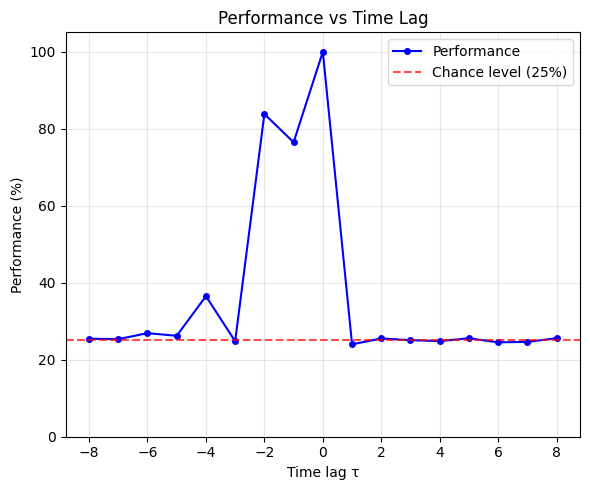

In [ ]:
plt.figure(figsize=(6, 5))

# Plot performance
plt.plot(tau_array, performance_arr,
            color='blue', marker='o', linestyle='-', markersize=4,
            label='Performance')

# Add chance level line at 25%
plt.axhline(y=25, color='red', linestyle='--', label='Chance level (25%)', alpha=0.7)

# Labels and formatting
plt.xlabel('Time lag τ')
plt.ylabel('Performance (%)')
plt.title('Performance vs Time Lag')
plt.ylim(0, 105)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()